# Serving You, or Shaping You?
## An Investigation of Algorithmic Influence on the Short-Video Dataset


**Group 24 members:** Yu Han · Shijie Li · Sifan Huang

---

> *Companion notebook to the data story website. This notebook documents
> the data, methods, code, and design decisions behind the analysis. All
> figures shown here are the same ones that appear on the website. The
> narrative is told there; here we explain how we got there.*


---

# 1. Motivation

## What is the dataset?

We use **KuaiRand-1K**, a publicly released sequential recommendation
dataset from Kuaishou (one of China's largest short-video platforms),
described in *Gao et al., 2022* (full citation in §8). KuaiRand is
distinctive among recommendation datasets because of how it was
collected:

- During the data-collection period (April 22 – May 8, 2022), Kuaishou
  ran an **online experiment in production**: roughly 0.4% of videos
  shown to users were sampled uniformly at random instead of being
  chosen by the recommendation algorithm.
- These randomly-exposed videos were inserted into otherwise-normal
  user sessions, alongside algorithm-picked videos, in the same feed.
- KuaiRand-1K is the 1,000-user subset of this experiment, containing
  **~6.7 million interaction events**, each labeled with a flag
  (`is_rand`) indicating whether that specific video was
  algorithm-recommended or randomly inserted.

For every interaction, the dataset records: the video shown, the user,
the timestamp, play duration, video duration, and **twelve feedback
signals** including `is_click`, `is_like`, `is_follow`, `is_comment`,
`is_forward`, `is_hate`, and `long_view`.

## Why this dataset?

Standard recommendation datasets only contain logs of what the
algorithm chose to show — there is no counterfactual. You cannot ask
*"what would have happened if a different video were shown to the same
user?"* because no such data exists.

KuaiRand is the rare exception. The random-exposure events constitute
a **natural A/B test embedded in a real product**: the same users, in
the same sessions, encounter both algorithm-picked and randomly-picked
videos. Comparing user reactions to these two event types isolates the
effect of the algorithm itself, without confounding it with
self-selection (e.g., heavy users behaving differently from light
users) or platform-specific factors.

This is what makes the dataset uniquely well-suited to our research
question:

> **Is the short-video algorithm serving users (giving them what they
> already want), or shaping them (changing what they do)?**

## What is the goal for the end user?

The intended end users of this project are **general readers who use
short-video apps but have never thought critically about how the
recommendation algorithm affects them**. The website tells a five-act
story designed to:

1. **Confirm a familiar feeling** — that the algorithm is uncannily
   good at picking videos they want to watch.
2. **Challenge a familiar fear** — the "filter bubble" narrative,
   which our data shows does *not* hold within a single browsing session.
3. **Reframe the conversation** — the algorithm shapes behavior (how
   long you stay, how often you return), not taste (what kinds of
   content you see).
4. **Hand the ethical question back to the reader**, without
   prescribing an answer.

This notebook is the technical companion to that story. It documents
every analytical choice, walks through the most important code
fragments, and reports the figures the website is built on.


---

# 2. Basic Stats

This section explains the data-cleaning choices that produced the
analysis table used throughout §3. We describe the choices in prose;
the code that implements them lives in the original analysis notebook.

## 2.1 The dataset, as it arrives

KuaiRand-1K ships as several separate CSV files. The two that matter
for our analysis are the **interaction logs**:

- `log_standard_4_22_to_5_08_1k.csv` — every interaction where the
  recommendation algorithm chose the video (~6.6 million rows)
- `log_random_4_22_to_5_08_1k.csv` — every interaction where the
  platform inserted a randomly-selected video instead (~30 thousand rows)

Each row records one user × one video interaction, with a timestamp
(`time_ms`) and the twelve feedback signals.

A third file, `video_features_basic_1k.csv`, provides metadata for each
video — most importantly, a `tag` field that we use to derive a
single-label `category` per video.

## 2.2 The central preprocessing decision — reconstructing the session

The website's analysis stands on one foundational data structure:
**user sessions with positional ordering**. Without this structure, we
cannot ask any of the within-session questions (Does diversity narrow
as a session progresses? Does Top-1 category share rise with position?
Where do the first vs the last videos in a session differ?). Building
this structure cleanly took two coordinated steps.

### Step 1 — Merge standard and random logs into a single timeline

On disk, the standard and random logs look like two separate streams.
But on the user's screen they were a single interleaved feed: a user
saw an algorithm-picked video, then another, then occasionally a
randomly-inserted one, then back to algorithm picks, all within the
same continuous scrolling experience.

We reconstruct that real timeline by concatenating the two CSV files
and sorting by `(user_id, time_ms)`. We then tag every row with an
`event_type` derived from the `is_rand` flag — `standard` for
algorithm-picked, `random` for inserted. This becomes the treatment
indicator for every downstream comparison.

**Why this matters:** if we had analyzed the two logs separately, the
random events would look like a parallel feed nobody actually used.
Merged, they reveal themselves as *occasional intruders* inside
otherwise-normal sessions — which is the correct mental model for the
algorithm-vs-random comparison the website is built on.

### Step 2 — Split the merged timeline into sessions at 30-minute gaps

Within each user's merged timeline, we compute the gap between
consecutive events. Wherever the gap exceeds **30 minutes**, we start
a new session. This produces a `session_id` column that uniquely
identifies each browsing session a user had.

We chose 30 minutes for three reasons:

1. It is the conventional threshold in web-session analysis literature.
2. It matches typical short-video viewing patterns — most active
   sessions are minutes-long with sub-second gaps between videos; a
   30-minute pause almost always means the user left and came back later.
3. We test sensitivity to this choice in §3.6 (robustness). At 15 / 45 /
   60 minutes, the qualitative conclusions are unchanged — the gap
   between standard and random engagement persists across all four
   thresholds.

### Step 3 — Number each event within its session (`seq_pos`)

Once sessions are defined, we add a per-session **sequence position**
column, `seq_pos`. The first event in a session gets `seq_pos = 1`,
the second gets `2`, and so on. This is the single column that makes
Figures D and 4 possible: "at the N-th video in a session, what does
the algorithm tend to show?" cannot be asked without it.

We also compute a `session_len` column (total number of events in each
session) so that downstream analyses can filter to sessions long
enough to be meaningful — we typically require `session_len ≥ 6` for
within-session comparisons.

## 2.3 Supporting preprocessing decisions

Several other small but consequential choices shape the analysis
table. We list them briefly here for completeness.

- **Category from first tag.** Videos can carry multiple tags. We take
  the first tag in the comma-separated `tag` field as the video's
  primary `category`. This loses some multi-label information but
  gives us one well-defined categorical variable per video — necessary
  for the Top-1-share and unique-category analyses. The alternative
  (multi-label categories) would complicate every aggregation without
  strengthening the conclusions.

- **`play_ratio = play_time_ms / duration_ms`, clipped at 3×.** When
  `duration_ms = 0` we mark the ratio as NaN. We clip at 3× because
  `play_time_ms` can substantially exceed `duration_ms` when a user
  loops a short video; without clipping, a few power-loopers would
  dominate every distribution.

- **User activity tier.** We split users at the 33rd and 66th
  percentiles of total interaction count into `low` / `mid` / `high`
  activity tiers, giving us three equal-sized groups. This lets us
  test whether the algorithm's behavior differs for casual users
  versus power users (Figures C, D, E in §3).

## 2.4 What the cleaned table looks like

After all preprocessing, the analysis table contains **6.7 million
rows** across **~1,000 users** and tens of thousands of distinct
videos. The temporal span is **17 days** (April 22 – May 8, 2022),
which bounds the questions we can answer:

- Within-session questions (positions 1–30 of a single browsing
  session) are well-supported.
- Cross-day questions (does the algorithm's behavior change over
  17 days?) are weakly supported.
- Cross-month or cross-year questions (the timescale where filter-
  bubble effects are most commonly alleged) are **not** supported.
  This is a fundamental limitation of the dataset and shapes how we
  frame our conclusions throughout the website.

The headline numbers:

- **Standard events:** ~6.6 million (99.6%)
- **Random events:** ~30 thousand (0.4%)
- **Median session length:** 31 videos (standard) vs 1 video (random)
- **Date range:** 17 days

The 99.6 / 0.4 split is by design: random insertions are a costly
product intervention, and Kuaishou inserts them sparingly to avoid
degrading the user experience for ordinary users. The headline
1-video-vs-31-video median session-length gap is the engine of the
website's Act II.


---

# 3. Data Analysis

## Overview — what we did

Our analytical approach is deliberately simple. The KuaiRand random-
exposure design produces a clean counterfactual (algorithm-picked vs
randomly-picked videos shown to the same users in the same sessions),
which means a well-chosen aggregation answers the research question
without sophisticated modeling. We do **not** apply machine learning:
our question is causal-descriptive ("what changes when the algorithm
doesn't choose?"), not predictive ("what will the user click next?").
Adding a model would not strengthen the conclusions and would risk
obscuring the comparison.

The analysis proceeds in three logical phases, mirroring the three
substantive findings of the website:

1. **Engagement comparison** — does the algorithm produce dramatically
   higher engagement than chance? (Figures A and B)
2. **Within-session content trajectory** — does the algorithm
   progressively narrow what each user sees within a single browsing
   session? This is the most direct test of the filter-bubble
   hypothesis. (Figures C, D, E)
3. **Robustness and consistency** — do the headline findings hold
   across app entry points, user-activity tiers, and alternative
   session-gap thresholds? (Figure F and robustness tables)

The rest of this section runs the code that produces every figure on
the website. We narrate the **three key findings in highlight boxes**
and let the remaining figures speak for themselves (full per-figure
explanations live in the website's chart-notes).

## 3.1 Setup, data loading, and descriptive statistics

We import libraries, load and merge the two log files, join video
metadata, and inspect the basic shape of the data.


In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

plt.style.use('ggplot')
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 200)

ROOT = Path.cwd().resolve()
PROJECT_B = ROOT.parent if ROOT.name == 'notebooks' else ROOT / 'projectB'

DATA_RAW = PROJECT_B / 'data_raw' / 'KuaiRand-1K' / 'data'
DATA_PROCESSED = PROJECT_B / 'data_processed'
FIG_DIR = PROJECT_B / 'figures'
WEB_DIR = PROJECT_B / 'website_assets'

for p in [DATA_PROCESSED, FIG_DIR, WEB_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('DATA_RAW =', DATA_RAW)

In [ ]:
df_std = pd.read_csv(DATA_RAW / 'log_standard_4_22_to_5_08_1k.csv')
df_rand = pd.read_csv(DATA_RAW / 'log_random_4_22_to_5_08_1k.csv')

df_raw = pd.concat([df_std, df_rand], ignore_index=True)
df_raw = df_raw.sort_values(['user_id', 'time_ms']).reset_index(drop=True)

df_raw['event_type'] = np.where(df_raw['is_rand'] == 1, 'random', 'standard')

print(f'Total rows:    {len(df_raw):,}')
print(f'  standard:    {(df_raw["event_type"]=="standard").sum():,}')
print(f'  random:      {(df_raw["event_type"]=="random").sum():,}')
print(f'  rand ratio:  {df_raw["is_rand"].mean():.4%}')

In [ ]:
# Join category from video_features_basic (tag field, take first tag)
meta_path = DATA_RAW / 'video_features_basic_1k.csv'
if meta_path.exists():
    df_meta = pd.read_csv(meta_path, usecols=['video_id', 'tag'])
    df_meta['category'] = df_meta['tag'].astype(str).str.split(',').str[0]
    df_meta = df_meta[['video_id', 'category']].drop_duplicates('video_id')
    df_raw = df_raw.merge(df_meta, on='video_id', how='left')
    print(f'Category coverage: {df_raw["category"].notna().mean():.2%}')
else:
    print('WARNING: video_features_basic not found')

df_raw['dt'] = pd.to_datetime(df_raw['time_ms'], unit='ms', errors='coerce')
df_raw.head(3)

In [ ]:
summary = {
    'total_rows': len(df_raw),
    'unique_users': df_raw['user_id'].nunique(),
    'unique_videos': df_raw['video_id'].nunique(),
    'date_range': f"{df_raw['dt'].min().date()} ~ {df_raw['dt'].max().date()}",
    'memory_MB': round(df_raw.memory_usage(deep=True).sum()/1024/1024, 1),
    'std_events': (df_raw['event_type']=='standard').sum(),
    'rand_events': (df_raw['event_type']=='random').sum(),
}
pd.DataFrame([summary]).T.rename(columns={0: 'value'})

The 99.6% / 0.4% standard-vs-random split is by design — random
insertions are a costly product intervention and the platform uses
them sparingly. The full date range is 17 days (April 22 – May 8,
2022), which is what bounds our temporal claims.

Next, the baseline rate of each feedback signal across all events
(this becomes **Fig 0** in our internal numbering, retained here for
transparency but folded into Figure A on the website):


In [ ]:
# Feedback signal overview
feedback_cols = ['is_click','is_like','is_follow','is_comment','is_forward','is_hate','long_view']
rates = df_raw[feedback_cols].mean().sort_values(ascending=True) * 100  # convert to %

fig, ax = plt.subplots(figsize=(8, 4))
rates.plot.barh(ax=ax, color='#4C72B0')
ax.set_xlabel('Overall Rate (%)')
ax.set_title('Fig 0: Feedback Signal Rates (all events)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig0_feedback_rates.png', dpi=150)
fig.savefig(WEB_DIR / 'fig0_feedback_rates.png', dpi=150)
plt.show()

Two signals — `is_click` (~37%) and `long_view` (~26%) — dominate
the others by an order of magnitude. The rarer signals (`is_like`
~1.6%, `is_follow` and `is_comment` below 0.5%) carry less
statistical weight in the downstream comparisons; we lean primarily
on click and long-view rates.

## 3.2 Session construction

The single most important preprocessing step, described in detail in
§2: split each user's merged timeline into sessions at 30-minute
gaps, then number events within each session (`seq_pos`). All of the
within-session analyses below depend on this column.


In [ ]:
df = df_raw.copy()

# play_ratio
df['play_ratio'] = np.where(
    df['duration_ms'] > 0,
    df['play_time_ms'] / df['duration_ms'],
    np.nan
)
# cap at 3x (user may replay)
df['play_ratio'] = df['play_ratio'].clip(upper=3.0)

# Session split: 30 min gap on merged timeline
SESSION_GAP = pd.Timedelta(minutes=30)
df = df.sort_values(['user_id', 'dt']).copy()
df['prev_dt'] = df.groupby('user_id')['dt'].shift(1)
df['new_session'] = ((df['dt'] - df['prev_dt']) > SESSION_GAP).fillna(True).astype(int)
df['session_id'] = df.groupby('user_id')['new_session'].cumsum()
df['seq_pos'] = df.groupby(['user_id', 'session_id']).cumcount() + 1

# Session length
session_lens = df.groupby(['user_id', 'session_id']).size().rename('session_len')
df = df.merge(session_lens.reset_index(), on=['user_id', 'session_id'], how='left')

# User activity level
u_cnt = df.groupby('user_id').size().rename('n_interactions')
q33, q66 = u_cnt.quantile([0.33, 0.66])
user_level = u_cnt.map(lambda x: 'low' if x <= q33 else ('mid' if x <= q66 else 'high'))
user_level = user_level.rename('user_level').reset_index()
user_info = pd.merge(user_level, u_cnt.reset_index(), on='user_id')
df = df.merge(user_info, on='user_id', how='left')

print(f'Sessions: {df[["user_id","session_id"]].drop_duplicates().shape[0]:,}')
print(f'Median session len: {session_lens.median():.0f}')
print(f'User levels: {df.groupby("user_level")["user_id"].nunique().to_dict()}')

df.to_csv(DATA_PROCESSED / 'analysis_table_v2.csv', index=False)

## 3.3 Finding 1 — The engagement gap is large and system-wide

> **What we learned:** Users react dramatically more strongly to
> algorithm-picked videos than to randomly-inserted ones, across every
> measurable feedback dimension. Long-view rate is roughly **3×**
> higher (26.1% vs 8.4%); click rate is **2×** higher (37.7% vs
> 17.4%); like rate is nearly **3×** higher. The watch-completion
> distribution shows this is not a marginal advantage but a fundamental
> shift in user behavior — about **60% of random videos are dismissed
> before the user has watched even 5%** of them, while about **17% of
> algorithm videos are watched in full and then rewatched**.

This is the finding that animates Act II of the website. The code
below computes mean rates by `event_type` for five engagement metrics
(Figure A), then plots the cumulative distribution of `play_ratio`
(Figure B). The CDF view is what reveals the distribution-shape
difference — see §5.3 for why this chart type was essential.


In [ ]:
# Fig A: Multi-metric comparison
metrics = {
    'long_view': 'Long View Rate',
    'is_click': 'Click Rate',
    'is_like': 'Like Rate',
    'is_follow': 'Follow Rate',
    'is_hate': 'Hate Rate',
}

metric_data = []
for col, label in metrics.items():
    for et in ['standard', 'random']:
        val = df.loc[df['event_type'] == et, col].mean()
        metric_data.append({'metric': label, 'event_type': et, 'rate': val})
metric_df = pd.DataFrame(metric_data)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics))
w = 0.35
std_vals = metric_df[metric_df['event_type']=='standard']['rate'].values * 100
rand_vals = metric_df[metric_df['event_type']=='random']['rate'].values * 100
bars1 = ax.bar(x - w/2, std_vals, w, label='Standard (algorithm)', color='#4C72B0')
bars2 = ax.bar(x + w/2, rand_vals, w, label='Random (inserted)', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(list(metrics.values()), rotation=15)
ax.set_ylabel('Rate (%)')
ax.set_title('Fig A: User Engagement — Algorithm vs Random Videos')
ax.legend()
# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.2, f'{h:.1f}%', ha='center', va='bottom', fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / 'figA_engagement_comparison.png', dpi=150)
fig.savefig(WEB_DIR / 'figA_engagement_comparison.png', dpi=150)
plt.show()

In [ ]:
# Fig B: play_ratio CDF
fig, ax = plt.subplots(figsize=(7, 5))
for et, color, ls in [('standard', '#4C72B0', '-'), ('random', '#DD8452', '--')]:
    vals = df.loc[df['event_type'] == et, 'play_ratio'].dropna()
    vals_sorted = np.sort(vals)
    cdf = np.arange(1, len(vals_sorted)+1) / len(vals_sorted) * 100  # to %
    vals_pct = vals_sorted * 100  # to %
    idx = np.linspace(0, len(vals_sorted)-1, min(2000, len(vals_sorted)), dtype=int)
    ax.plot(vals_pct[idx], cdf[idx], color=color, linestyle=ls, label=f'{et} (median={np.median(vals_sorted)*100:.1f}%)')
ax.set_xlim(0, 200)
ax.set_xlabel('Play Ratio (%)')
ax.set_ylabel('CDF (%)')
ax.set_title('Fig B: Watch Completion — Algorithm vs Random')
ax.legend()
ax.axvline(100, color='gray', alpha=0.3, linestyle=':')
ax.text(102, 50, 'watched 100%', rotation=90, color='gray', alpha=0.5, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'figB_play_ratio_cdf.png', dpi=150)
fig.savefig(WEB_DIR / 'figB_play_ratio_cdf.png', dpi=150)
plt.show()

## 3.4 Finding 2 — The filter bubble does not appear within a session

> **What we learned:** The standard filter-bubble prediction — that
> algorithmic curation progressively narrows the content each user
> sees — does **not** hold within the 17-day, single-session timescale
> of this dataset. From position 1 to position 10 of a session, the
> share of the most popular category falls from 18–21% down to
> 12–15%, then plateaus. Sessions become *more* diverse in their
> second half, not less. And at the per-user level, nearly every
> individual user encounters more distinct content categories under
> the algorithm than under random insertion.

This is the reversal in Act III of the website. The three figures
below approach the same question from three different angles —
first-half vs second-half (C), Top-1 share by position (D), and
per-user scatter (E). All three converge on the same conclusion.

This finding is also the one we did not expect when we started. The
direction of the evidence forced us to rewrite the project's central
thesis from "algorithms create bubbles" to "algorithms shape time,
not taste" (see §6).


In [ ]:
# Split each session into first-half and second-half
df['half'] = np.where(df['seq_pos'] <= df['session_len'] / 2, 'first_half', 'second_half')

# Only std events for category analysis
df_std_only = df[df['event_type'] == 'standard'].copy()

# Minimum session length for meaningful analysis
min_session = 6
long_sessions = df_std_only[df_std_only['session_len'] >= min_session]

if 'category' in long_sessions.columns:
    # Category diversity by half
    cat_div = (long_sessions.groupby(['user_level', 'user_id', 'session_id', 'half'])
               ['category'].nunique().rename('n_cat').reset_index())
    cat_div_agg = cat_div.groupby(['user_level', 'half'])['n_cat'].mean().reset_index()

    fig, ax = plt.subplots(figsize=(8, 5))
    levels = ['low', 'mid', 'high']
    x = np.arange(len(levels))
    w = 0.35
    for i, half in enumerate(['first_half', 'second_half']):
        vals = []
        for lvl in levels:
            row = cat_div_agg[(cat_div_agg['user_level']==lvl) & (cat_div_agg['half']==half)]
            vals.append(row['n_cat'].values[0] if len(row) else 0)
        offset = -w/2 if i == 0 else w/2
        color = '#4C72B0' if i == 0 else '#DD8452'
        ax.bar(x + offset, vals, w, label=half, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(['Low Activity', 'Mid Activity', 'High Activity'])
    ax.set_ylabel('Avg # Unique Categories (std events)')
    ax.set_title('Fig C: Content Diversity — First Half vs Second Half of Session')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'figC_session_diversity_halves.png', dpi=150)
    fig.savefig(WEB_DIR / 'figC_session_diversity_halves.png', dpi=150)
    plt.show()

In [ ]:
# Fig D: Top1 category share by seq_pos (std events only), by user_level
if 'category' in df_std_only.columns:
    max_pos = 30
    pos_data = df_std_only[df_std_only['seq_pos'] <= max_pos].copy()

    rows_d = []
    for (lvl, pos), grp in pos_data.groupby(['user_level', 'seq_pos']):
        vc = grp['category'].value_counts(dropna=True)
        share = (vc.iloc[0] / vc.sum()) if len(vc) else np.nan
        rows_d.append({'user_level': lvl, 'seq_pos': pos, 'top1_share': share})
    top1_df = pd.DataFrame(rows_d)

    fig, ax = plt.subplots(figsize=(9, 5))
    colors = {'low': '#55A868', 'mid': '#4C72B0', 'high': '#C44E52'}
    for lvl in ['low', 'mid', 'high']:
        sub = top1_df[top1_df['user_level'] == lvl].sort_values('seq_pos')
        if len(sub):
            ax.plot(sub['seq_pos'], sub['top1_share'] * 100, marker='.', label=f'{lvl} activity', color=colors[lvl])
    ax.set_xlabel('Sequence Position in Session')
    ax.set_ylabel('Top-1 Category Share (%)')
    ax.set_title('Fig D: Content Concentration Over Session (Algorithm Recommendations)')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'figD_top1_by_position.png', dpi=150)
    fig.savefig(WEB_DIR / 'figD_top1_by_position.png', dpi=150)
    plt.show()

In [ ]:
if 'category' in df.columns:
    user_div = df.groupby(['user_id', 'user_level', 'event_type'])['category'].nunique().reset_index()
    user_div = user_div.rename(columns={'category': 'n_cat'})
    user_div_wide = user_div.pivot_table(index=['user_id', 'user_level'], columns='event_type', values='n_cat').reset_index()
    user_div_wide = user_div_wide.dropna(subset=['standard', 'random'])

    fig, ax = plt.subplots(figsize=(7, 6))
    colors_map = {'low': '#55A868', 'mid': '#4C72B0', 'high': '#C44E52'}
    for lvl in ['low', 'mid', 'high']:
        sub = user_div_wide[user_div_wide['user_level'] == lvl]
        ax.scatter(sub['random'], sub['standard'], alpha=0.5, s=20, label=f'{lvl}', color=colors_map[lvl])
    lim = max(user_div_wide['standard'].max(), user_div_wide['random'].max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='equal line')
    ax.set_xlabel('# Unique Categories (random events)')
    ax.set_ylabel('# Unique Categories (standard events)')
    ax.set_title('Fig E: Per-User Content Diversity')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'figE_user_diversity_scatter.png', dpi=150)
    fig.savefig(WEB_DIR / 'figE_user_diversity_scatter.png', dpi=150)
    plt.show()

## 3.5 Scenario consistency (Figure F)

A short check that the engagement gap is not localized to one app
entry point. KuaiRand's `tab` field records which interface the user
entered through. After filtering to tabs with ≥ 1000 events and ≥ 10
random events, only `tab=1` and `tab=2` survive — both show large,
same-direction gaps (long-view gap ≈ 0.23–0.28, click gap ≈ 0.27–0.31).
The algorithm's advantage is a system-level property, not an artifact
of a particular interface.


In [ ]:
tab_counts = df['tab'].value_counts()
top_tabs = tab_counts[tab_counts >= 1000].index.tolist()[:6]
print(f'Top tabs (≥1000 events): {top_tabs}')

tab_data = []
for t in top_tabs:
    sub = df[df['tab'] == t]
    for et in ['standard', 'random']:
        s = sub[sub['event_type'] == et]
        if len(s) >= 10:
            tab_data.append({
                'tab': f'tab={t}',
                'event_type': et,
                'long_view_rate': s['long_view'].mean(),
                'click_rate': s['is_click'].mean(),
                'n': len(s)
            })
tab_df = pd.DataFrame(tab_data)

if len(tab_df):
    # Compute engagement gap
    gap_rows = []
    for t in tab_df['tab'].unique():
        s_row = tab_df[(tab_df['tab']==t) & (tab_df['event_type']=='standard')]
        r_row = tab_df[(tab_df['tab']==t) & (tab_df['event_type']=='random')]
        if len(s_row) and len(r_row):
            gap_rows.append({
                'tab': t,
                'long_view_gap': s_row['long_view_rate'].values[0] - r_row['long_view_rate'].values[0],
                'click_gap': s_row['click_rate'].values[0] - r_row['click_rate'].values[0],
            })
    gap_df = pd.DataFrame(gap_rows).sort_values('long_view_gap', ascending=True)

    fig, ax = plt.subplots(figsize=(8, 5))
    y = np.arange(len(gap_df))
    ax.barh(y, gap_df['long_view_gap'], color='#4C72B0', alpha=0.8, label='Long View Gap')
    ax.barh(y, gap_df['click_gap'], color='#DD8452', alpha=0.6, left=0, label='Click Gap', height=0.4)
    ax.set_yticks(y)
    ax.set_yticklabels(gap_df['tab'])
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Rate Gap (standard − random)')
    ax.set_title('Fig F: Engagement Gap by Scenario (tab)')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'figF_scenario_gap.png', dpi=150)
    fig.savefig(WEB_DIR / 'figF_scenario_gap.png', dpi=150)
    plt.show()

## 3.6 Interactive exploration

Two Plotly charts for §6 of the website: a per-user engagement
scatter (Interactive 1, the user-level version of Figure E) and an
hourly heatmap of feedback rates (Interactive 2). These are
exploration tools rather than findings — we do not draw conclusions
from them in the website text, because the random-event sample sizes
per cell are too small for confident hour-level inference.


In [ ]:
# Interactive 1: Per-user engagement scatter (percentagized)
user_eng = df.groupby(['user_id', 'user_level', 'event_type']).agg(
    play_ratio_mean=('play_ratio', 'mean'),
    long_view_rate=('long_view', 'mean'),
    n=('video_id', 'size')
).reset_index()

ue_wide = user_eng.pivot_table(
    index=['user_id', 'user_level'],
    columns='event_type',
    values=['play_ratio_mean', 'long_view_rate', 'n']
).reset_index()
ue_wide.columns = ['_'.join(c).strip('_') for c in ue_wide.columns]

# Only keep users with both types
ue_wide = ue_wide.dropna(subset=['play_ratio_mean_standard', 'play_ratio_mean_random'])

# Convert to percentage for display
ue_wide['pr_std_pct'] = (ue_wide['play_ratio_mean_standard'] * 100).round(2)
ue_wide['pr_rand_pct'] = (ue_wide['play_ratio_mean_random'] * 100).round(2)
ue_wide['lv_std_pct'] = (ue_wide['long_view_rate_standard'] * 100).round(2)
ue_wide['lv_rand_pct'] = (ue_wide['long_view_rate_random'] * 100).round(2)

fig_i1 = px.scatter(
    ue_wide,
    x='pr_rand_pct',
    y='pr_std_pct',
    color='user_level',
    size='n_standard',
    size_max=15,
    custom_data=['user_level', 'pr_std_pct', 'pr_rand_pct', 'lv_std_pct', 'lv_rand_pct'],
    color_discrete_map={'low': '#55A868', 'mid': '#4C72B0', 'high': '#C44E52'},
    title='Interactive 1: Per-User Watch Completion — Algorithm vs Random',
    labels={
        'pr_rand_pct': 'Avg Play Ratio — Random (%)',
        'pr_std_pct': 'Avg Play Ratio — Algorithm (%)',
        'user_level': 'Activity Level'
    }
)
fig_i1.update_traces(
    hovertemplate=(
        '<b>Activity Level</b>: %{customdata[0]}<br>'
        'Avg Play Ratio (algorithm): %{customdata[1]:.2f}%<br>'
        'Avg Play Ratio (random): %{customdata[2]:.2f}%<br>'
        'Long View Rate (algorithm): %{customdata[3]:.2f}%<br>'
        'Long View Rate (random): %{customdata[4]:.2f}%'
        '<extra></extra>'
    )
)
fig_i1.add_trace(go.Scatter(
    x=[0, 200], y=[0, 200], mode='lines',
    line=dict(dash='dash', color='gray'), showlegend=False
))
fig_i1.update_layout(width=800, height=600)
fig_i1.write_html(WEB_DIR / 'interactive1_user_engagement.html')
fig_i1.show()

In [ ]:
# Interactive 2: Hourly feedback heatmap (all events merged)
df['hour'] = df['dt'].dt.hour

hourly = []
for h in range(24):
    sh = df[df['hour'] == h]
    if len(sh):
        hourly.append({
            'hour': h,
            'Long View (%)': sh['long_view'].mean() * 100,
            'Click (%)': sh['is_click'].mean() * 100,
            'Like (%)': sh['is_like'].mean() * 100,
            'Hate (%)': sh['is_hate'].mean() * 100,
            'n_events': len(sh),
        })
hourly_df = pd.DataFrame(hourly).sort_values('hour')

feedback_types = ['Long View (%)', 'Click (%)', 'Like (%)', 'Hate (%)']
z = [hourly_df[fb].values for fb in feedback_types]

fig_i2 = go.Figure(data=go.Heatmap(
    z=z, x=hourly_df['hour'], y=feedback_types,
    colorscale='YlOrRd',
    hovertemplate='Hour: %{x}<br>%{y}: %{z:.2f}%<extra></extra>'
))
fig_i2.update_layout(
    title='Interactive 2: How Users Engage Throughout the Day (All Events)',
    xaxis_title='Hour of Day',
    width=900, height=400
)
fig_i2.write_html(WEB_DIR / 'interactive2_hourly_heatmap.html')
fig_i2.show()

## 3.7 Finding 3 — The headline conclusions are robust

> **What we learned:** The 30-minute session-gap threshold is a
> conventional choice, but our findings should not depend on it. At
> 15, 30, 45, and 60-minute thresholds, the standard-vs-random
> engagement gap remains positive and of comparable magnitude.
> Filtering out very inactive users (those with fewer than 5
> interactions) also leaves the gap essentially unchanged. The
> headline conclusions are not artifacts of either an arbitrary
> session boundary or a small population of disengaged users.


In [ ]:
# Robustness: session gap sensitivity
def engagement_by_gap(data, gap_min):
    gap = pd.Timedelta(minutes=gap_min)
    x = data.sort_values(['user_id', 'dt']).copy()
    x['prev_dt_r'] = x.groupby('user_id')['dt'].shift(1)
    x['ns_r'] = ((x['dt'] - x['prev_dt_r']) > gap).fillna(True).astype(int)
    x['sid_r'] = x.groupby('user_id')['ns_r'].cumsum()
    sl = x.groupby(['user_id', 'sid_r']).size().rename('slen')
    # Compute session-level aggregated metrics (these DO change with gap)
    sess_lv = x.groupby(['user_id', 'sid_r', 'event_type'])['long_view'].mean().reset_index()
    sess_pr = x.groupby(['user_id', 'sid_r', 'event_type'])['play_ratio'].mean().reset_index()
    return {
        'gap_min': gap_min,
        'n_sessions': len(sl),
        'median_session_len': sl.median(),
        'std_long_view_sess': sess_lv[sess_lv['event_type']=='standard']['long_view'].median(),
        'rand_long_view_sess': sess_lv[sess_lv['event_type']=='random']['long_view'].median(),
        'std_play_ratio_sess': sess_pr[sess_pr['event_type']=='standard']['play_ratio'].median(),
        'rand_play_ratio_sess': sess_pr[sess_pr['event_type']=='random']['play_ratio'].median(),
    }

robust = pd.DataFrame([engagement_by_gap(df, g) for g in [15, 30, 45, 60]])
print('Robustness check across session gap thresholds:')
robust

In [ ]:
# Robustness: exclude users with < 5 interactions
active = df[df['n_interactions'] >= 5]
print(f'After filtering: {active["user_id"].nunique()} users, {len(active):,} rows')
print('Long view rate — std:', active[active['event_type']=='standard']['long_view'].mean().round(4))
print('Long view rate — rand:', active[active['event_type']=='random']['long_view'].mean().round(4))

**Summary of analysis.** The dataset supports three claims with
high confidence: the algorithm produces a 2–3× engagement gap across
every dimension; this gap does not come at the cost of within-session
content narrowing; and both findings are robust to the session-gap
threshold and to user-activity filtering. What the dataset cannot
support — and we are explicit about this in §6 — is any claim about
longer-timescale (multi-week or multi-month) narrowing, which is the
timescale where filter-bubble effects are most commonly alleged.

---

# 4. Genre

Which genre of data story did we use? Following the framework in
*Segal & Heer, 2010* (Figure 7), we positioned the website as a hybrid
of **Magazine Style** and **Annotated Chart**:

- **Magazine Style** — long-form editorial layout, body text alternating
  with figures, a clear authorial voice that walks the reader through
  a five-act argument.
- **Annotated Chart** — every figure carries a *"What to notice"*
  caption that explicitly points to the part of the chart that
  matters, rather than letting the reader interpret it cold.

The website is not a slideshow (the reader scrolls continuously
rather than advancing through discrete frames) and not a comic strip
(figures are interleaved with prose, not arranged sequentially with
panels). Magazine Style fit the editorial, argument-driven nature of
our story; Annotated Chart fit the need to make each figure's role in
the argument unambiguous.

## 4.1 Visual Narrative tools (the three categories)

Segal & Heer classify Visual Narrative tools into three categories.
We made one principal choice from each:

| Category | Tool we used | Why |
|---|---|---|
| **Visual Structuring** | Consistent layout grid — a fixed left rail (Act number, marker) and a right column (body text and figures) running through every section. | The reader builds an intuition for where the next piece of evidence will appear, which lets us spend their attention on the content rather than on re-orienting them each time. |
| **Highlighting** | Per-figure colored badges (`HEADLINE`, `REVERSAL`, `SHAPING`) and pull-quotes between acts that crystallize the takeaway. | Our story has a turning point (the filter-bubble reversal in Act III). The badge system tells the reader, before they read the caption, what role each figure plays in the argument. Pull-quotes give the reader natural pause points. |
| **Transition Guidance** | Explicit bridging paragraphs at the end of each act that pose the question the next act will answer (e.g., *"What's the cost?"* at the end of Act II → Act III tests filter bubble). | The act-to-act transitions are the riskiest part of a long-form data story. Bridges keep the reader from having to reconstruct the argument's logic on their own. |

## 4.2 Narrative Structure tools (the three categories)

| Category | Choice we made | Why |
|---|---|---|
| **Ordering** | **Linear, author-driven** for the main spine (Acts I → V). | The argument depends on a specific reveal sequence (set up → confirm → reverse → reframe → return). A non-linear order would let the reader hit the filter-bubble reversal before the engagement-gap setup, which would weaken the surprise. |
| **Interactivity** | **Reader-driven** in §6 (interactive Plotly scatter and hourly heatmap), but only after the linear argument has been completed. | We wanted readers who finished the argument to have a way to interrogate it at the individual-user level. Placing interactivity *after* the linear narrative (rather than throughout) prevents the exploration tools from competing for attention with the main argument. |
| **Messaging** | Strong, named takeaway at the end of each act (e.g., *"The algorithm doesn't shrink your world."*) rather than letting figures speak for themselves. | The story has a non-obvious thesis (the algorithm shapes time, not taste). Without explicit messaging, a reader could plausibly walk away with the wrong takeaway from any individual figure. |

The combination — strict author-driven linear ordering for the
argument, reader-driven exploration after the argument, strong
messaging throughout — is what Segal & Heer term a **martini-glass
structure**: a narrow linear stem (the five acts) opening into a wider
exploratory bowl (§6). This is the structure we adopted.


---

# 5. Visualizations

The assignment asks two questions about our visualization choices.
We answer each in turn, then walk through **Figure B** (Watch
Completion CDF) in detail as the centerpiece example — it is the chart
where our chart-type choice did the most analytical work — and bring
in Figures D and E briefly as supporting examples.

## 5.1 What visualizations did we choose?

The website's main spine uses **nine static figures plus two
interactive charts**, drawn from a deliberately conservative palette
of chart types:

- **Vertical and grouped bar charts** for direct rate comparisons —
  Figures 5b (median session length), A (multi-metric engagement),
  C (first vs second half diversity), and F (gap by scenario).
- **Line charts** for trends over an ordinal axis — Figure D (Top-1
  share by sequence position), where the X-axis is a position counter
  within a session.
- **Cumulative distribution function (CDF)** for shape comparisons —
  Figure B (play-ratio CDF), where the *distribution shape* of how
  much each video is watched matters as much as its mean.
- **Scatter plot with a y=x reference line** for individual-level
  comparisons — Figure E (per-user category diversity), where the
  reference line is itself the analytical claim.
- **Overlapping density histogram** for distribution comparisons —
  Figure 5c (revisit-interval distribution).
- **Horizontal bar with gap-encoded values** for differences —
  Figure F (scenario gap, encoded as standard minus random).
- **Interactive Plotly scatter and heatmap** for §6's exploration
  section, with hover-revealed exact values.

We chose this palette to be **familiar rather than novel**. The story
itself has a counter-intuitive thesis (the algorithm shapes time, not
taste). When the *argument* is the surprising thing, the *visuals*
should not also be surprising — that would split the reader's
attention. Every chart type used here is one a typical reader will
have encountered before, which means the cognitive budget is spent
parsing what the chart says, not learning how to read it.

We also chose a strict two-color contrast — **blue (#4C72B0) for
algorithm, orange (#DD8452) for random** — reserved exclusively for
the algorithm-vs-random comparison. Where user-activity tier needs to
be encoded simultaneously (Figures D and E), we switch to a separate
green/blue/red palette so the colors do not collide. A reader who
learns "blue = algorithm" in Figure 5b can carry that association
through the whole site.

## 5.2 Why are these the right charts for the story we want to tell?

Three criteria drove every choice:

**1. The chart should encode the claim directly, not require the
reader to compute the claim themselves.** Where our argument is "the
algorithm widens the menu," the chart should not show two raw
quantities and ask the reader to subtract — it should encode the
difference itself. This is why Figure F uses gap-as-bar rather than
two-bars-and-let-you-compare, and why Figure D's trend line goes
*down* (against bubble theory) rather than asking the reader to
interpret an upward or sideways trend.

**2. The chart should match the level of the claim.** Where the
argument is about averages, a bar suffices. Where the argument is
about distributions (Figure B, discussed in detail below), a CDF is
necessary because a bar would hide the long-tail behavior that the
claim depends on. Where the argument is about *individuals* (Figure
E), neither a bar nor a CDF suffices — only a scatter shows per-user
variation, which is what the claim is about.

**3. The chart should be defensible against a skeptical reading.**
When a finding is unexpected — and our central finding (no within-
session narrowing) is unexpected — the chart should make alternative
explanations visible rather than hidden. This is why Figure D shows
three lines (low / mid / high activity) rather than one pooled line:
a reader who suspects the result is being driven by one user segment
can check each segment independently.

## 5.3 Centerpiece example: Figure B — Watch Completion CDF

Figure B is the chart where our choice of chart type carried the most
analytical weight. It also illustrates each of the three criteria
above in a single visualization.

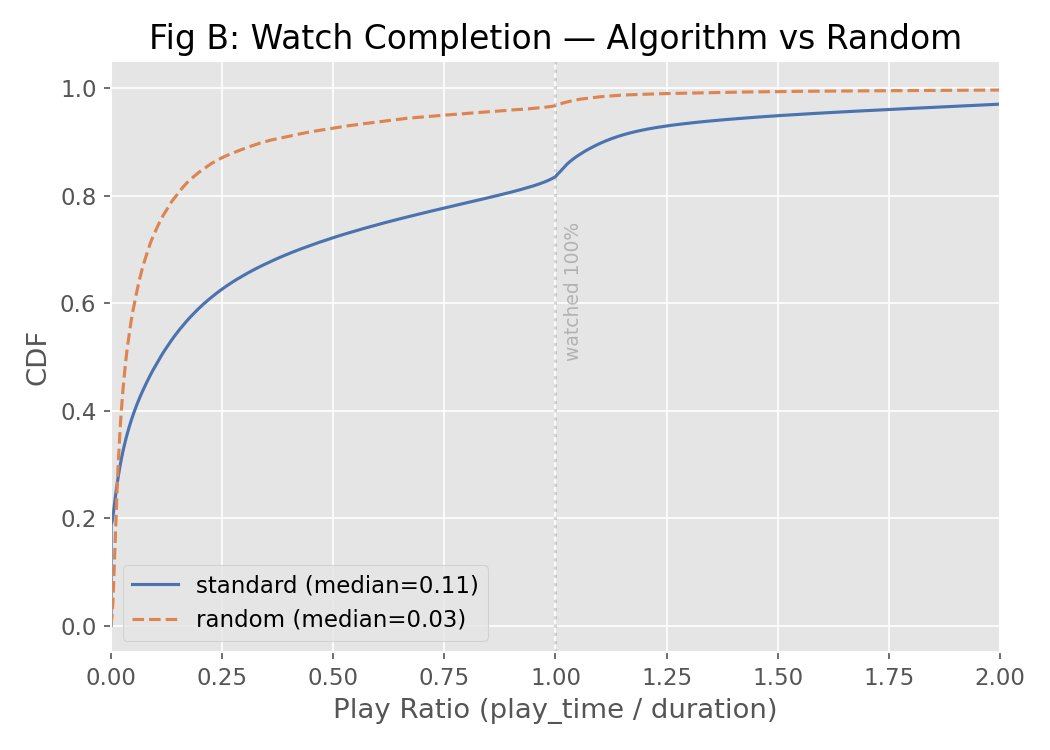

### What Figure B shows

A cumulative distribution function (CDF) of `play_ratio = play_time
/ duration`, plotted separately for `standard` (blue, solid) and
`random` (orange, dashed) events.

- **X-axis:** play_ratio. 0 means the video was not watched at all;
  1.0 means it was watched exactly once through; values above 1.0
  indicate rewatching.
- **Y-axis:** proportion of interactions with play_ratio at or below
  that X value.
- **Vertical gray dashed line at x = 1.0**: marks the "watched 100%"
  threshold.
- **Legend:** reports the median for each curve directly — standard
  median = 0.11, random median = 0.03.

### Why this chart type was the right choice

A naïve version of this comparison would be a **single bar chart**:
"average play_ratio for algorithm = 0.X, for random = 0.Y." That
chart would be five times smaller and would also be wrong. Here's
why we chose the CDF instead.

**A bar chart would have hidden the shape of the gap.** Two
distributions with the same mean can differ enormously in shape, and
in this case the *shape* difference is more interesting than the mean
difference. Roughly 60% of random-video interactions have play_ratio
below 0.05 — users barely glance at them before swiping away. That
fact is invisible in a mean: it lives in the steep left rise of the
orange curve. A CDF makes this immediately readable as "where does
each curve cross the 60% line on the Y-axis?" The orange curve crosses
near 0.05 on the X-axis; the blue curve crosses much further to the
right.

**The right tail is part of the story, not noise to be trimmed.**
The X-axis extends past 1.0 to capture rewatching behavior. At x = 1.0
the blue CDF sits around 0.83, meaning roughly **17% of algorithm
videos are watched in full and then rewatched**. The corresponding
number for random is only ~4%. A histogram with reasonable bin widths
would crush this tail into a thin sliver at the right edge; the
linear CDF preserves it as a visibly long, gently rising plateau
that the reader can actually read off.

**Two curves on shared axes let a reader read the gap at every
quantile, not just at the median.** A grouped bar chart would have
forced us to pick a summary statistic and report only that one number.
The CDF instead shows the gap at every percentile of the distribution
simultaneously. A skeptical reader can ask "what about the 90th
percentile?" or "what about the median?" and answer their own
question by looking at the chart. This satisfies criterion #3
(defensible against skeptical reading) almost effortlessly: the chart
contains many more comparisons than we explicitly make in the text.

### Design choices inside the chart

Three small decisions that mattered:

- **Solid vs dashed line styles** in addition to color. We could have
  relied on color alone (blue vs orange), but the dashed style for
  `random` makes the comparison legible even in grayscale
  reproduction or for color-blind readers. The two curves can be
  distinguished without color.
- **Median annotated in the legend.** Rather than relying on the
  reader to mentally locate the y = 0.5 line and trace it down to
  the X-axis, we report the median directly in the legend strings:
  `"standard (median=0.11)"`, `"random (median=0.03)"`. The most
  important summary statistic appears twice — once in the chart's
  geometry, once as text.
- **The "watched 100%" reference line.** A vertical dashed line at
  x = 1.0, with a rotated label, marks the qualitative threshold
  ("watched the whole video") that separates *partial* viewing from
  *rewatching*. This is a domain-meaningful boundary, not just a
  numeric value, and naming it on the chart relieves the reader from
  having to know in advance that 1.0 means "100% watched."

### What Figure B accomplishes that no other chart in the project does

It is the only figure on the website where we make a **distribution-
shape claim** rather than a summary-statistic claim. Every other
figure compares two means, two counts, or two rates — collapsing
distributions into single numbers. Figure B is the one place where the
collapse would have destroyed the finding. Without the CDF, the
website's claim that "60% of random videos are barely watched at
all" would have no visible evidence behind it — and that claim is
load-bearing for the headline-level argument that the algorithm makes
users *unwilling to swipe away*.

## 5.4 Supporting examples — Figures D and E

The same three criteria apply to other figures. Two brief examples:

### Figure D — Top-1 category share by session position

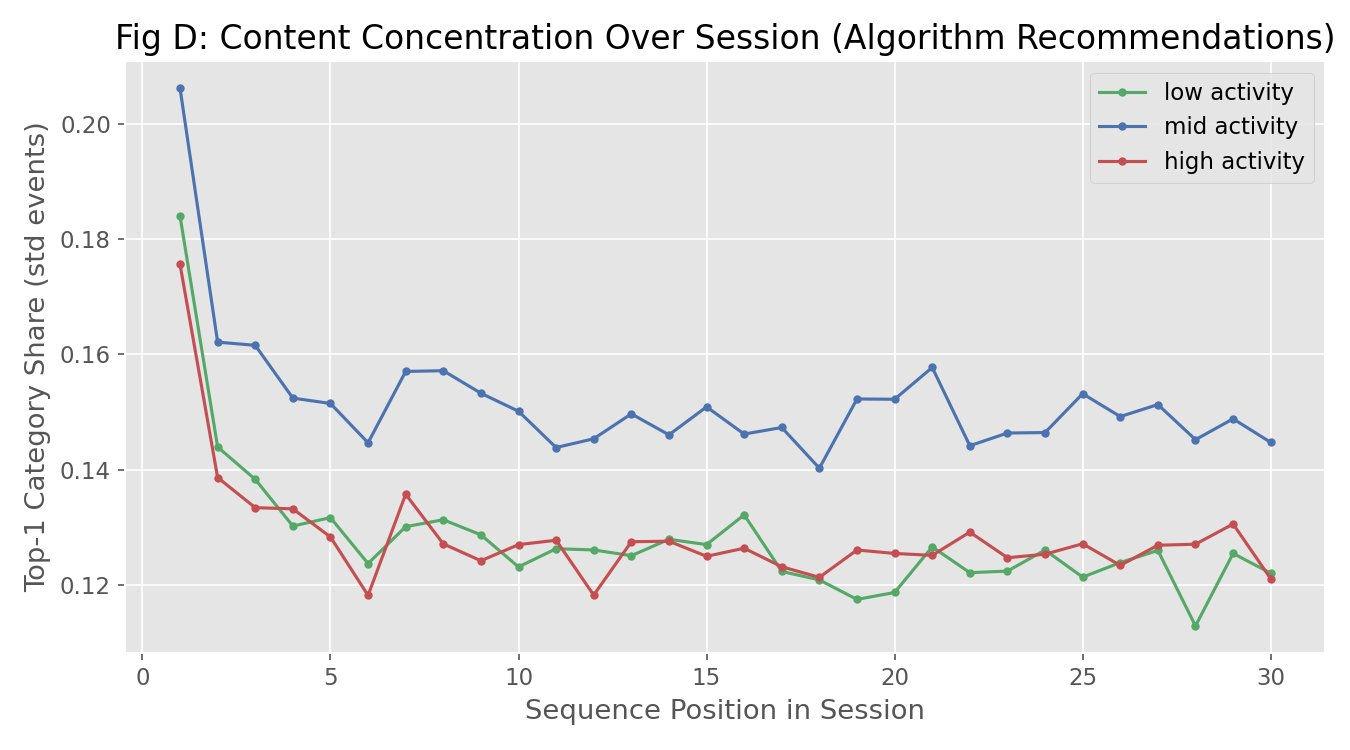

The chart type (line chart) was chosen because the X-axis is an
ordinal time variable (sequence position within a session). A bar
chart would have made the *direction of trend* hard to read; a line
makes it obvious at a glance that the lines fall and then plateau.
Three lines stratify by user activity, satisfying criterion #3 — a
skeptical reader can check that the no-narrowing pattern holds across
all three tiers, not just on average.

### Figure E — Per-user content diversity scatter

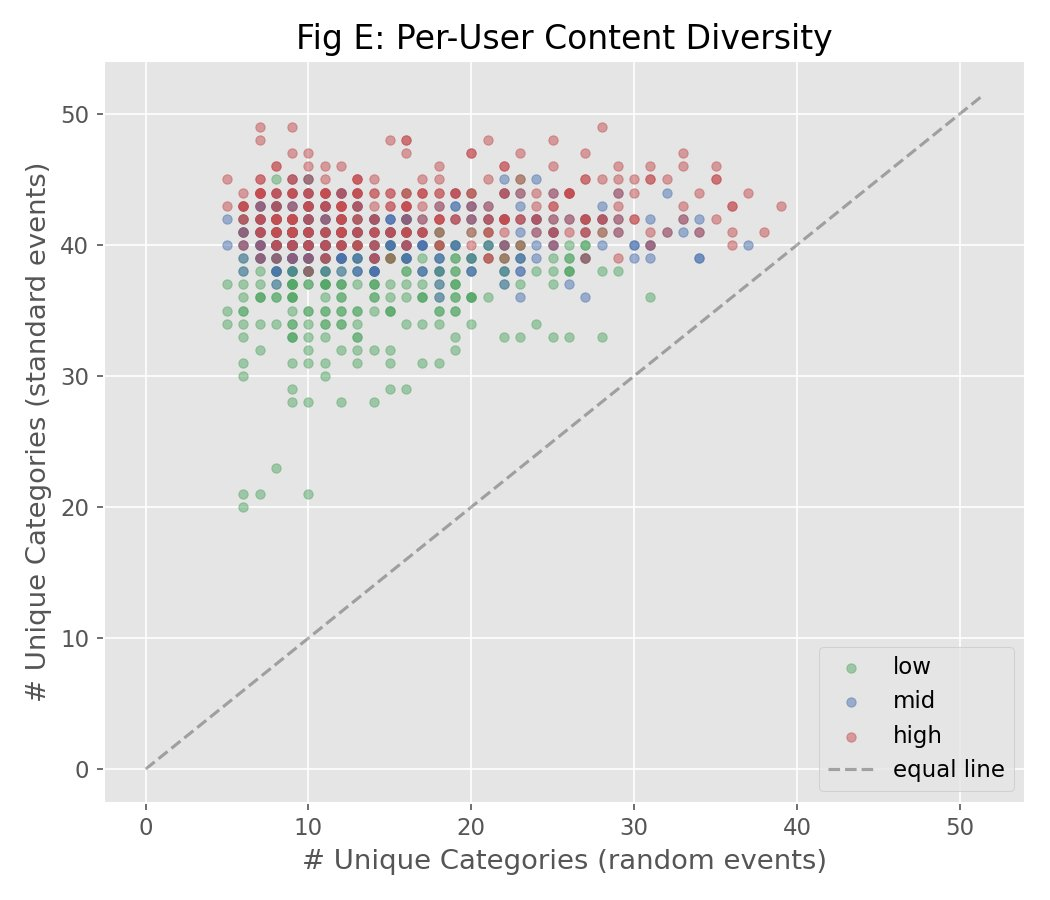

The chart type (scatter with y=x reference line) was chosen because
the claim is about *individuals*, not averages. A bar chart of mean
diversity would have hidden whether the algorithm-vs-random gap holds
for every user or only on average. The y=x line is the analytical
claim itself made visible: anything above the line is a user whose
algorithm exposure exceeded their random exposure. A reader doesn't
compute the comparison; they just look at where the cloud sits.

Together, Figures B, D, and E illustrate the family resemblance
across all our charts: encode the claim directly, match the chart
type to the level of the claim, and stratify or annotate wherever a
skeptical reader might want to push back.

---

# 6. Discussion

## 6.1 What went well

**The reframing held up.** Our central analytical contribution is the
distinction between *taste-shaping* (which the data does not support
at the within-session timescale) and *time-shaping* (which it strongly
supports). This was not the framing we started with — we initially
expected to find evidence for the filter bubble and report it. The
data forced us to rewrite the thesis, and the rewritten thesis is more
defensible and more interesting than the original one would have been.

**The natural experiment did the heavy lifting.** Because KuaiRand's
random-exposure design produces a clean counterfactual, we did not
need complex causal-inference methods (matching, propensity scores,
instrumental variables). Simple aggregation by `event_type` answers
the question. This is a property of the dataset, not the analysis —
but choosing the right dataset was a deliberate decision worth
crediting.

**The five-act narrative structure forced disciplined cuts.** Going
from sixteen exploratory figures to nine main-spine figures + two
interactives required us to identify what each figure was *for* in
the argument. Figures that didn't earn their place were cut. The
resulting story is denser per figure than our first draft.

## 6.2 What's still missing — three principal limitations

**1. We can only speak to *within-session* effects.** The filter-
bubble finding (no narrowing) is robust within a single browsing
session, but the entire 17-day data window is too short to test for
narrowing across weeks or months. A user whose taste is being slowly
homogenized over a year would not show up in this analysis. The
filter-bubble debate has historically been about long-timescale
effects (years of YouTube recommendations shaping a person's
politics), and our data simply cannot adjudicate that version of the
claim.

**2. Random-exposure events have no algorithmic "warm-up."** When the
algorithm shows you a video, the platform has typically been priming
you toward similar content for hours or days beforehand — through
related autoplays, similar recommendations, search-suggestion
adjustments. A randomly-inserted video gets none of this. Some of the
algorithm-vs-random engagement gap therefore reflects an *onboarding
asymmetry*, not purely the quality of the algorithmic choice itself.
We have no principled way to disentangle these in the data as
released. The gap we report is therefore an upper bound on the
algorithm's pure selection contribution.

**3. Behavioral signals are not psychological measurements.** Our
entire analysis runs on click, watch, like, follow — behavioral
traces. We infer "satisfaction" from completion rates and
"habituation" from revisit intervals, but neither inference is
direct. Two users with identical play_ratios may be having entirely
different psychological experiences (one engrossed, one mindlessly
scrolling). We are explicit about this in the website's closing
question, but it bears repeating that "shaping time" is a behavioral
claim, not a claim about the phenomenology of short-video use.

## 6.3 What we'd do next

Three natural extensions:

- **Cross-session analysis.** A larger dataset (or a longer time
  window) would let us test for taste-narrowing on the timescale where
  it is most plausible.
- **User survey overlay.** Pairing the behavioral data with even a
  small user survey would help calibrate the behavior-to-psychology
  bridge that §6.2 (point 3) flags as unmeasured.
- **Cross-platform replication.** KuaiRand is Kuaishou-specific.
  Whether the within-session-no-narrowing finding generalizes to
  TikTok, YouTube Shorts, or Reels is an open question — and each of
  those platforms has different incentives and feed mechanics.


---

# 7. Contributions

> *To be completed by the group. Below is a task inventory the group
> can use to fill in responsibility. Multiple lead names are allowed
> where work was genuinely shared.*

## Project task inventory

| # | Task | Lead(s) |
|---|---|---|
| A | Problem framing & research question (*"serving or shaping?"*) | Shijie Li, Sifan Huang, Yu Han |
| B | Background research and literature review (filter-bubble, recommender systems) | Shijie Li, Yu Han |
| C | Dataset selection and evaluation (why KuaiRand) | Shijie Li, Sifan Huang, Yu Han |
| D | Data loading and preprocessing (merging std/rand logs, session splitting, feature engineering) | Shijie Li, Yu Han |
| E | Exploratory data analysis (feedback signal rates, session-length distribution) | Shijie Li, Yu Han |
| F | Engagement comparison analysis (Figures A, B) | Yu Han |
| G | Session progression analysis (Figures C, D, E) | Shijie Li, Sifan Huang, Yu Han |
| H | Scenario and robustness analysis (Figure F + robustness checks) | Shijie Li, Sifan Huang, Yu Han |
| I | Interactive visualization (Plotly Interactive 1 & 2) | Yu Han |
| J | Narrative design (five-act / eight-section structure, story arc) | Yu Han |
| K | Website front-end implementation (HTML / CSS / responsive layout) | Shijie Li, Yu Han |
| L | Website copywriting (headlines, captions, pull-quotes) | Shijie Li, Sifan Huang, Yu Han |
| M | Explainer notebook structure and documentation | Shijie Li, Sifan Huang, Yu Han |




---

# 8. References

1. **Gao, C., Li, S., Zhang, Y., Chen, J., Li, B., Lei, W., Jiang, P., & He, X. (2022).**
   *KuaiRand: An Unbiased Sequential Recommendation Dataset with Randomly
   Exposed Videos.* In *Proceedings of the 31st ACM International Conference
   on Information and Knowledge Management (CIKM '22)*, Atlanta, GA, USA.
   ACM, New York, NY, USA, 6 pages.
   [https://doi.org/10.1145/3511808.3557624](https://doi.org/10.1145/3511808.3557624)

   *— The dataset paper. The random-exposure design described in §1 of
   their paper is what makes the natural experiment in this notebook
   possible.*

2. **Segal, E., & Heer, J. (2010).**
   *Narrative Visualization: Telling Stories with Data.*
   *IEEE Transactions on Visualization and Computer Graphics, 16(6),
   1139–1148.*
   [https://doi.org/10.1109/TVCG.2010.179](https://doi.org/10.1109/TVCG.2010.179)

   *— The source of the visual-narrative and narrative-structure
   taxonomies used in §4. The "martini-glass" structure referenced in
   §4.2 is from this paper.*

3. **Pariser, E. (2011).**
   *The Filter Bubble: What the Internet Is Hiding from You.*
   *Penguin Press, New York.*

   *— The popular-press origin of the filter-bubble concept tested
   (and largely overturned, at the within-session timescale) by our
   analysis in §3.4.*

---

*End of notebook.*
